## Do practice improvements predict reductions in vulnerability? 

In [49]:
import pandas as pd
import polars as pl
import polars.selectors as cs
import seaborn as sns
from settings import load_settings
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.pipeline import Pipeline
from matplotlib import pyplot as plt
settings = load_settings()

df = pl.read_parquet(settings.research_question_1_dataset_path)

In [10]:
df.head()

package_name,github_repo,package_depended_on_count,package_total_downloads,github_repo_age_in_years,github_repo_commit_staleness_in_days,github_repo_contributions_count,github_repo_size_in_kb,aggregated_score,vul_count,mttr,mttu
str,str,u32,i64,f64,i64,i64,i64,f64,i64,f64,f64
"""python-qnotifications""","""dschreij/qnotifications""",1,11694,9.93,1963,2,6684,3.6,10,null,null
"""pywavelets""","""pywavelets/pywt""",55,122976480,12.65,15,57,14831,4.3,10,0.0,0.0
"""osmxtract""","""yannforget/osmxtract""",0,7974,7.76,2475,1,15,3.0,10,null,null
"""gplately""","""gplates/gplately""",0,9955,4.72,29,11,998196,null,null,0.0,0.574785
"""manga-ocr""","""kha-white/manga-ocr""",0,122364,4.16,275,9,1122,3.9,4,0.0,1.323817


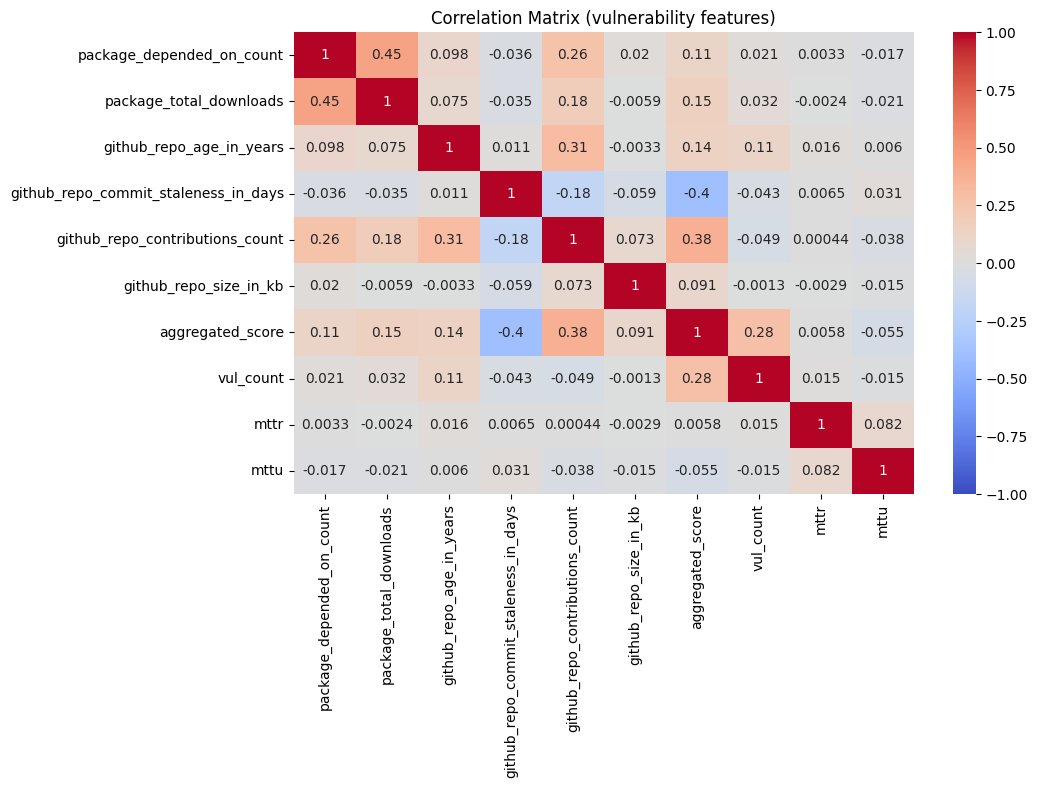

In [30]:
plt.figure(figsize=(10, 6))
numeric_df = df.select(cs.numeric())
corr_df = numeric_df.drop_nulls().corr().to_pandas()
sns.heatmap(corr_df, annot=True, yticklabels=corr_df.columns, xticklabels=corr_df.columns, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix (vulnerability features)")
plt.show()

In [32]:
features = [
    'package_depended_on_count', 'package_total_downloads', 
    'github_repo_age_in_years', 'github_repo_commit_staleness_in_days', 
    'github_repo_contributions_count', 'github_repo_size_in_kb', 'aggregated_score'
]

X = df[features]
y = df['vul_count']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 37423
Testing set size: 9356


In [53]:
combined = X_train.with_columns(target=y_train)
cleaned = combined.filter(pl.col("target").is_not_null())
X_train_clean = cleaned.drop("target")
y_train_clean = cleaned.select("target").to_series()

pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipeline, X_train_clean, y_train_clean, cv=kf, scoring='neg_mean_absolute_error')
print(f"Training Cross-Validation MAE: {-cv_scores.mean():.4f}")
pipeline.fit(X_train_clean, y_train_clean)
print("R2 Score on Training Set:", r2_score(y_train_clean, pipeline.predict(X_train_clean)))

Training Cross-Validation MAE: 1.3759
R2 Score on Training Set: 0.9231535507540296


In [54]:
from sklearn.metrics import mean_absolute_error
test_combined = X_test.with_columns(target=y_test)
test_cleaned = test_combined.filter(pl.col("target").is_not_null())
X_test_clean = test_cleaned.drop("target")
y_test_clean = test_cleaned.select("target").to_series()

pipeline.fit(X_train_clean.to_numpy(), y_train_clean.to_numpy())
y_pred = pipeline.predict(X_test_clean.to_numpy())
final_mae = mean_absolute_error(y_test_clean, y_pred)
print(f"Final Test MAE: {final_mae:.4f}")
r2_score = r2_score(y_test_clean, y_pred)
print(f"R2 Score on Test Set: {r2_score:.4f}")

Final Test MAE: 1.3849
R2 Score on Test Set: 0.4362


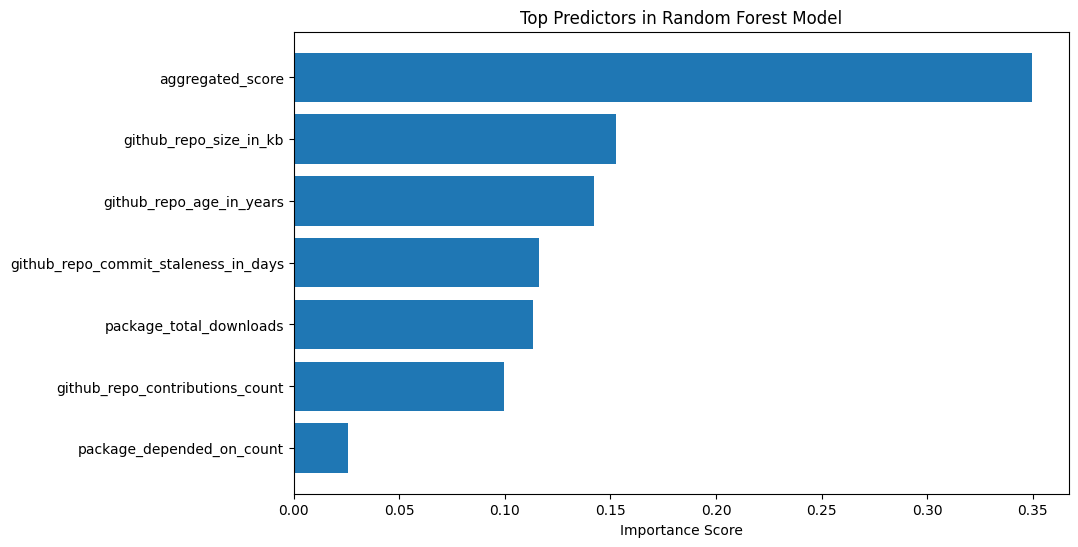

In [55]:
rf_model = pipeline.named_steps['model']
feature_names = X_train_clean.columns
importances = pd.DataFrame({
    'feature': feature_names,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importances['feature'], importances['importance'])
plt.gca().invert_yaxis()  # most important at top
plt.xlabel('Importance Score')
plt.title('Top Predictors in Random Forest Model')
plt.show()